In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import KFold, cross_validate
from sklearn.model_selection import GridSearchCV

from pathlib import Path
import json
import joblib

from project_paths import PROCESSED_DIR

import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature
print(mlflow.__version__)


3.10.1


In [2]:
MLFLOW_DB_PATH = ROOT / "mlflow.db"
mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB_PATH.as_posix()}")
mlflow.set_experiment("projet-12-baselines")

print("MLflow version :", mlflow.__version__)
print("Tracking URI :", mlflow.get_tracking_uri())

MLflow version : 3.10.1
Tracking URI : sqlite:///C:/Users/thoma/Documents/Openclassroom/Projet-12/mlflow.db


In [3]:
crop_aux = pd.read_csv(PROCESSED_DIR / "crop_aux_clean.csv")
crop_aux_enriched = pd.read_csv(PROCESSED_DIR / "crop_aux_enriched.csv")

print(crop_aux.shape)
print(crop_aux_enriched.shape)

(999769, 10)
(999769, 18)


In [4]:
sample_size = 200_000
random_state = 42

crop_aux_sample = crop_aux.sample(n=sample_size, random_state=random_state)
crop_aux_enriched_sample = crop_aux_enriched.sample(n=sample_size, random_state=random_state)

print(crop_aux_sample.shape)
print(crop_aux_enriched_sample.shape)

(200000, 10)
(200000, 18)


In [5]:
target_col = "Yield_tons_per_hectare"

base_features = [
    "Region",
    "Soil_Type",
    "Crop",
    "Rainfall_mm",
    "Temperature_Celsius",
    "Fertilizer_Used",
    "Irrigation_Used",
    "Weather_Condition",
    "Days_to_Harvest",
]

X_base = crop_aux_sample[base_features].copy()
y_base = crop_aux_sample[target_col].copy()

In [6]:
crop_aux_enriched_sample.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare,Crop_std,ext_mean_temp_by_crop,ext_mean_rainfall_by_crop,ext_mean_pesticides_by_crop,ext_n_obs_by_crop,ext_mean_yield_by_crop,rainfall_gap_vs_crop_profile,temp_gap_vs_crop_profile
352142,West,Peaty,Rice,423.756311,39.298567,False,True,Cloudy,71,4.378713,Rice,20.798107,1221.097204,16443.811451,1502.0,37541.646471,-797.340893,18.500460
30783,South,Loam,Barley,156.270440,20.391569,False,False,Sunny,85,1.589250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
479365,North,Silt,Soybean,914.253783,34.803208,True,True,Sunny,120,8.032276,Soybean,18.225843,1135.826087,20043.068696,1242.0,16563.747987,-221.572304,16.577365
55589,North,Silt,Soybean,856.558093,35.352312,False,True,Cloudy,102,6.163982,Soybean,18.225843,1135.826087,20043.068696,1242.0,16563.747987,-279.267994,17.126469
493689,East,Silt,Maize,796.598674,15.957662,True,True,Cloudy,83,6.424947,Maize,19.248136,1105.724852,13722.443030,2030.0,36959.517241,-309.126178,-3.290473


In [7]:
enriched_features = [
    "Region",
    "Soil_Type",
    "Crop",
    "Rainfall_mm",
    "Temperature_Celsius",
    "Fertilizer_Used",
    "Irrigation_Used",
    "Weather_Condition",
    "Days_to_Harvest",
    "ext_mean_temp_by_crop",
    "ext_mean_rainfall_by_crop",
    "ext_mean_pesticides_by_crop",
    "ext_n_obs_by_crop",
    "rainfall_gap_vs_crop_profile",
    "temp_gap_vs_crop_profile",
]

X_enriched = crop_aux_enriched_sample[enriched_features].copy()
y_enriched = crop_aux_enriched_sample[target_col].copy()

In [8]:
base_numeric_features = [
    "Rainfall_mm",
    "Temperature_Celsius",
    "Days_to_Harvest",
]

base_categorical_features = [
    "Region",
    "Soil_Type",
    "Crop",
    "Fertilizer_Used",
    "Irrigation_Used",
    "Weather_Condition",
]

X_base = crop_aux_sample[base_features].copy()
y_base = crop_aux_sample[target_col].copy()

for col in base_numeric_features:
    X_base[col] = pd.to_numeric(X_base[col], errors="coerce")

for col in base_categorical_features:
    X_base[col] = X_base[col].fillna("missing").astype("object")

In [9]:
enriched_numeric_features = [
    "Rainfall_mm",
    "Temperature_Celsius",
    "Days_to_Harvest",
    "ext_mean_temp_by_crop",
    "ext_mean_rainfall_by_crop",
    "ext_mean_pesticides_by_crop",
    "ext_n_obs_by_crop",
    "rainfall_gap_vs_crop_profile",
    "temp_gap_vs_crop_profile",
]

enriched_categorical_features = [
    "Region",
    "Soil_Type",
    "Crop",
    "Fertilizer_Used",
    "Irrigation_Used",
    "Weather_Condition",
]

X_enriched = crop_aux_enriched_sample[enriched_features].copy()
y_enriched = crop_aux_enriched_sample[target_col].copy()

for col in enriched_numeric_features:
    X_enriched[col] = pd.to_numeric(X_enriched[col], errors="coerce")

for col in enriched_categorical_features:
    X_enriched[col] = X_enriched[col].fillna("missing").astype("object")

In [10]:
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_base, y_base, test_size=0.2, random_state=random_state
)

Xe_train, Xe_test, ye_train, ye_test = train_test_split(
    X_enriched, y_enriched, test_size=0.2, random_state=random_state
)

In [11]:
def build_preprocessor(numeric_features, categorical_features):
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_pipeline = OneHotEncoder(handle_unknown="ignore")

    preprocessor = ColumnTransformer([
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ])

    return preprocessor

In [12]:
def evaluate_regression(y_true, y_pred, model_name: str, dataset_name: str) -> dict:
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        "dataset": dataset_name,
        "model": model_name,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
    }

In [13]:
models_extended = {
    "dummy_mean": DummyRegressor(strategy="mean"),
    "ridge": Ridge(alpha=1.0),
    "random_forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=None,
        random_state=random_state,
        n_jobs=-1,
    ),
    "hist_gbr": HistGradientBoostingRegressor(
        random_state=random_state
    ),
    "xgboost": XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=random_state,
        n_jobs=-1,
    ),
    "lightgbm": LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=random_state,
        verbosity=-1,
    ),
}

In [14]:
def run_model_benchmark_mlflow_extended(
    X_train,
    X_test,
    y_train,
    y_test,
    dataset_name: str,
    numeric_features,
    categorical_features,
):
    results = []

    for model_name, model in models_extended.items():
        preprocessor = build_preprocessor(
            numeric_features=numeric_features,
            categorical_features=categorical_features,
        )

        pipe = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model),
        ])

        run_name = f"{dataset_name}__{model_name}"

        with mlflow.start_run(run_name=run_name):
            mlflow.set_tags({
                "project": "Projet-12",
                "notebook": "03_modeling_baseline",
                "stage": "benchmark_extended",
                "dataset_name": dataset_name,
                "model_name": model_name,
            })

            mlflow.log_param("dataset_name", dataset_name)
            mlflow.log_param("model_name", model_name)
            mlflow.log_param("n_train_rows", len(X_train))
            mlflow.log_param("n_test_rows", len(X_test))
            mlflow.log_param("n_numeric_features", len(numeric_features))
            mlflow.log_param("n_categorical_features", len(categorical_features))

            if model_name == "ridge":
                mlflow.log_param("alpha", model.alpha)

            elif model_name == "random_forest":
                mlflow.log_param("n_estimators", model.n_estimators)
                mlflow.log_param("max_depth", model.max_depth)

            elif model_name == "hist_gbr":
                mlflow.log_param("learning_rate", model.learning_rate)
                mlflow.log_param("max_iter", model.max_iter)

            elif model_name == "xgboost":
                mlflow.log_param("n_estimators", model.n_estimators)
                mlflow.log_param("max_depth", model.max_depth)
                mlflow.log_param("learning_rate", model.learning_rate)

            elif model_name == "lightgbm":
                mlflow.log_param("n_estimators", model.n_estimators)
                mlflow.log_param("learning_rate", model.learning_rate)
                mlflow.log_param("num_leaves", model.num_leaves)

            pipe.fit(X_train, y_train)
            preds = pipe.predict(X_test)

            result = evaluate_regression(
                y_true=y_test,
                y_pred=preds,
                model_name=model_name,
                dataset_name=dataset_name,
            )

            mlflow.log_metric("rmse", result["rmse"])
            mlflow.log_metric("mae", result["mae"])
            mlflow.log_metric("r2", result["r2"])

            results.append(result)

    return pd.DataFrame(results)

In [15]:
def run_catboost_benchmark_mlflow(
    X_train,
    X_test,
    y_train,
    y_test,
    dataset_name: str,
    categorical_features,
):
    results = []

    X_train_cb = X_train.copy()
    X_test_cb = X_test.copy()

    for col in X_train_cb.columns:
        if col in categorical_features:
            X_train_cb[col] = X_train_cb[col].fillna("missing").astype(str)
            X_test_cb[col] = X_test_cb[col].fillna("missing").astype(str)
        else:
            X_train_cb[col] = pd.to_numeric(X_train_cb[col], errors="coerce")
            X_test_cb[col] = pd.to_numeric(X_test_cb[col], errors="coerce")

    cat_features_idx = [X_train_cb.columns.get_loc(col) for col in categorical_features]

    model = CatBoostRegressor(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        loss_function="RMSE",
        eval_metric="RMSE",
        random_state=random_state,
        verbose=0,
    )

    run_name = f"{dataset_name}__catboost"

    with mlflow.start_run(run_name=run_name):
        mlflow.set_tags({
            "project": "Projet-12",
            "notebook": "03_modeling_baseline",
            "stage": "benchmark_extended",
            "dataset_name": dataset_name,
            "model_name": "catboost",
        })

        mlflow.log_param("dataset_name", dataset_name)
        mlflow.log_param("model_name", "catboost")
        mlflow.log_param("iterations", model.get_params()["iterations"])
        mlflow.log_param("depth", model.get_params()["depth"])
        mlflow.log_param("learning_rate", model.get_params()["learning_rate"])

        model.fit(
            X_train_cb,
            y_train,
            cat_features=cat_features_idx,
        )

        preds = model.predict(X_test_cb)

        result = evaluate_regression(
            y_true=y_test,
            y_pred=preds,
            model_name="catboost",
            dataset_name=dataset_name,
        )

        mlflow.log_metric("rmse", result["rmse"])
        mlflow.log_metric("mae", result["mae"])
        mlflow.log_metric("r2", result["r2"])

        results.append(result)

    return pd.DataFrame(results)

In [16]:
results_base_ext = run_model_benchmark_mlflow_extended(
    Xb_train,
    Xb_test,
    yb_train,
    yb_test,
    dataset_name="crop_aux_base",
    numeric_features=base_numeric_features,
    categorical_features=base_categorical_features,
)

results_base_cat = run_catboost_benchmark_mlflow(
    Xb_train,
    Xb_test,
    yb_train,
    yb_test,
    dataset_name="crop_aux_base",
    categorical_features=base_categorical_features,
)

results_enriched_ext = run_model_benchmark_mlflow_extended(
    Xe_train,
    Xe_test,
    ye_train,
    ye_test,
    dataset_name="crop_aux_enriched",
    numeric_features=enriched_numeric_features,
    categorical_features=enriched_categorical_features,
)

results_enriched_cat = run_catboost_benchmark_mlflow(
    Xe_train,
    Xe_test,
    ye_train,
    ye_test,
    dataset_name="crop_aux_enriched",
    categorical_features=enriched_categorical_features,
)

results_all_extended = pd.concat(
    [
        results_base_ext,
        results_base_cat,
        results_enriched_ext,
        results_enriched_cat,
    ],
    ignore_index=True,
)

results_all_extended.sort_values(["dataset", "rmse"])

c:\Users\thoma\Documents\Openclassroom\Projet-12\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\thoma\AppData\Local\Temp\ipykernel_21884\3601897207.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train_cb[col] = X_train_cb[col].fillna("missing").astype(str)
C:\Users\thoma\AppData\Local\Temp\ipykernel_21884\3601897207.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test_cb[col] = X_test_cb[col].fillna("missin

,dataset,model,rmse,mae,r2
1,crop_aux_base,ridge,0.496723,0.396089,0.913939
6,crop_aux_base,catboost,0.497416,0.396681,0.913698
5,crop_aux_base,lightgbm,0.497990,0.397009,0.913499
3,crop_aux_base,hist_gbr,0.498269,0.397230,0.913402
4,crop_aux_base,xgboost,0.498590,0.397433,0.913290
2,crop_aux_base,random_forest,0.515372,0.410729,0.907355
0,crop_aux_base,dummy_mean,1.693210,1.385817,-0.000005
8,crop_aux_enriched,ridge,0.496710,0.396081,0.913943
13,crop_aux_enriched,catboost,0.497164,0.396507,0.913786
10,crop_aux_enriched,hist_gbr,0.498228,0.397223,0.913416


## Nouveau run avec feature ingeniring

In [17]:
def add_agro_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # booléens -> numériques pour interactions
    df["Fertilizer_Used_num"] = df["Fertilizer_Used"].astype(int)
    df["Irrigation_Used_num"] = df["Irrigation_Used"].astype(int)

    # termes quadratiques
    df["Rainfall_mm_sq"] = df["Rainfall_mm"] ** 2
    df["Temperature_Celsius_sq"] = df["Temperature_Celsius"] ** 2

    # interactions climat x pratiques
    df["Rainfall_x_Irrigation"] = df["Rainfall_mm"] * df["Irrigation_Used_num"]
    df["Temp_x_Irrigation"] = df["Temperature_Celsius"] * df["Irrigation_Used_num"]

    df["Rainfall_x_Fertilizer"] = df["Rainfall_mm"] * df["Fertilizer_Used_num"]
    df["Temp_x_Fertilizer"] = df["Temperature_Celsius"] * df["Fertilizer_Used_num"]

    # interactions climat x cycle cultural
    df["Rainfall_x_Days"] = df["Rainfall_mm"] * df["Days_to_Harvest"]
    df["Temp_x_Days"] = df["Temperature_Celsius"] * df["Days_to_Harvest"]

    return df

In [18]:
crop_aux_sample_fe = add_agro_features(crop_aux_sample)
crop_aux_enriched_sample_fe = add_agro_features(crop_aux_enriched_sample)

In [19]:
base_fe_features = [
    "Region",
    "Soil_Type",
    "Crop",
    "Rainfall_mm",
    "Temperature_Celsius",
    "Fertilizer_Used",
    "Irrigation_Used",
    "Weather_Condition",
    "Days_to_Harvest",
    "Rainfall_mm_sq",
    "Temperature_Celsius_sq",
    "Rainfall_x_Irrigation",
    "Temp_x_Irrigation",
    "Rainfall_x_Fertilizer",
    "Temp_x_Fertilizer",
    "Rainfall_x_Days",
    "Temp_x_Days",
]

In [20]:
enriched_fe_features = [
    "Region",
    "Soil_Type",
    "Crop",
    "Rainfall_mm",
    "Temperature_Celsius",
    "Fertilizer_Used",
    "Irrigation_Used",
    "Weather_Condition",
    "Days_to_Harvest",
    "ext_mean_temp_by_crop",
    "ext_mean_rainfall_by_crop",
    "ext_mean_pesticides_by_crop",
    "ext_n_obs_by_crop",
    "rainfall_gap_vs_crop_profile",
    "temp_gap_vs_crop_profile",
    "Rainfall_mm_sq",
    "Temperature_Celsius_sq",
    "Rainfall_x_Irrigation",
    "Temp_x_Irrigation",
    "Rainfall_x_Fertilizer",
    "Temp_x_Fertilizer",
    "Rainfall_x_Days",
    "Temp_x_Days",
]

In [21]:
X_base_fe = crop_aux_sample_fe[base_fe_features].copy()
y_base_fe = crop_aux_sample_fe[target_col].copy()

X_enriched_fe = crop_aux_enriched_sample_fe[enriched_fe_features].copy()
y_enriched_fe = crop_aux_enriched_sample_fe[target_col].copy()

In [22]:
base_fe_numeric_features = [
    "Rainfall_mm",
    "Temperature_Celsius",
    "Days_to_Harvest",
    "Rainfall_mm_sq",
    "Temperature_Celsius_sq",
    "Rainfall_x_Irrigation",
    "Temp_x_Irrigation",
    "Rainfall_x_Fertilizer",
    "Temp_x_Fertilizer",
    "Rainfall_x_Days",
    "Temp_x_Days",
]

base_fe_categorical_features = [
    "Region",
    "Soil_Type",
    "Crop",
    "Fertilizer_Used",
    "Irrigation_Used",
    "Weather_Condition",
]

In [23]:
enriched_fe_numeric_features = [
    "Rainfall_mm",
    "Temperature_Celsius",
    "Days_to_Harvest",
    "ext_mean_temp_by_crop",
    "ext_mean_rainfall_by_crop",
    "ext_mean_pesticides_by_crop",
    "ext_n_obs_by_crop",
    "rainfall_gap_vs_crop_profile",
    "temp_gap_vs_crop_profile",
    "Rainfall_mm_sq",
    "Temperature_Celsius_sq",
    "Rainfall_x_Irrigation",
    "Temp_x_Irrigation",
    "Rainfall_x_Fertilizer",
    "Temp_x_Fertilizer",
    "Rainfall_x_Days",
    "Temp_x_Days",
]

enriched_fe_categorical_features = [
    "Region",
    "Soil_Type",
    "Crop",
    "Fertilizer_Used",
    "Irrigation_Used",
    "Weather_Condition",
]

In [24]:
for col in base_fe_numeric_features:
    X_base_fe[col] = pd.to_numeric(X_base_fe[col], errors="coerce")

for col in base_fe_categorical_features:
    X_base_fe[col] = X_base_fe[col].fillna("missing").astype(str)

for col in enriched_fe_numeric_features:
    X_enriched_fe[col] = pd.to_numeric(X_enriched_fe[col], errors="coerce")

for col in enriched_fe_categorical_features:
    X_enriched_fe[col] = X_enriched_fe[col].fillna("missing").astype(str)

In [25]:
Xbf_train, Xbf_test, ybf_train, ybf_test = train_test_split(
    X_base_fe, y_base_fe, test_size=0.2, random_state=random_state
)

Xef_train, Xef_test, yef_train, yef_test = train_test_split(
    X_enriched_fe, y_enriched_fe, test_size=0.2, random_state=random_state
)

In [26]:
models_fe = {
    "ridge": Ridge(alpha=1.0),
    "hist_gbr": HistGradientBoostingRegressor(random_state=random_state),
}

In [27]:
def run_model_benchmark_mlflow_fe(
    X_train,
    X_test,
    y_train,
    y_test,
    dataset_name: str,
    numeric_features,
    categorical_features,
):
    results = []

    for model_name, model in models_fe.items():
        preprocessor = build_preprocessor(
            numeric_features=numeric_features,
            categorical_features=categorical_features,
        )

        pipe = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model),
        ])

        run_name = f"{dataset_name}__{model_name}"

        with mlflow.start_run(run_name=run_name):
            mlflow.set_tags({
                "project": "Projet-12",
                "notebook": "03_modeling_baseline",
                "stage": "feature_engineering",
                "dataset_name": dataset_name,
                "model_name": model_name,
            })

            mlflow.log_param("dataset_name", dataset_name)
            mlflow.log_param("model_name", model_name)
            mlflow.log_param("n_train_rows", len(X_train))
            mlflow.log_param("n_test_rows", len(X_test))
            mlflow.log_param("n_numeric_features", len(numeric_features))
            mlflow.log_param("n_categorical_features", len(categorical_features))

            if model_name == "ridge":
                mlflow.log_param("alpha", model.alpha)

            if model_name == "hist_gbr":
                mlflow.log_param("learning_rate", model.learning_rate)
                mlflow.log_param("max_iter", model.max_iter)

            pipe.fit(X_train, y_train)
            preds = pipe.predict(X_test)

            result = evaluate_regression(
                y_true=y_test,
                y_pred=preds,
                model_name=model_name,
                dataset_name=dataset_name,
            )

            mlflow.log_metric("rmse", result["rmse"])
            mlflow.log_metric("mae", result["mae"])
            mlflow.log_metric("r2", result["r2"])

            results.append(result)

    return pd.DataFrame(results)

In [28]:
results_base_fe = run_model_benchmark_mlflow_fe(
    Xbf_train,
    Xbf_test,
    ybf_train,
    ybf_test,
    dataset_name="crop_aux_base_fe",
    numeric_features=base_fe_numeric_features,
    categorical_features=base_fe_categorical_features,
)

results_enriched_fe = run_model_benchmark_mlflow_fe(
    Xef_train,
    Xef_test,
    yef_train,
    yef_test,
    dataset_name="crop_aux_enriched_fe",
    numeric_features=enriched_fe_numeric_features,
    categorical_features=enriched_fe_categorical_features,
)

results_fe_all = pd.concat(
    [results_all_extended, results_base_fe, results_enriched_fe],
    ignore_index=True,
)

results_fe_all.sort_values(["dataset", "rmse"])

,dataset,model,rmse,mae,r2
1,crop_aux_base,ridge,0.496723,0.396089,0.913939
6,crop_aux_base,catboost,0.497416,0.396681,0.913698
5,crop_aux_base,lightgbm,0.497990,0.397009,0.913499
3,crop_aux_base,hist_gbr,0.498269,0.397230,0.913402
4,crop_aux_base,xgboost,0.498590,0.397433,0.913290
2,crop_aux_base,random_forest,0.515372,0.410729,0.907355
0,crop_aux_base,dummy_mean,1.693210,1.385817,-0.000005
14,crop_aux_base_fe,ridge,0.496749,0.396086,0.913930
15,crop_aux_base_fe,hist_gbr,0.498291,0.397202,0.913394
8,crop_aux_enriched,ridge,0.496710,0.396081,0.913943


## Refit du champion pour extraction de coefficient et permutations

In [29]:
champion_model = Ridge(alpha=1.0)

champion_preprocessor = build_preprocessor(
    numeric_features=base_numeric_features,
    categorical_features=base_categorical_features,
)

champion_pipe = Pipeline([
    ("preprocessor", champion_preprocessor),
    ("model", champion_model),
])

champion_pipe.fit(Xb_train, yb_train)
champion_preds = champion_pipe.predict(Xb_test)

evaluate_regression(
    y_true=yb_test,
    y_pred=champion_preds,
    model_name="ridge_champion",
    dataset_name="crop_aux_base"
)

{'dataset': 'crop_aux_base',
 'model': 'ridge_champion',
 'rmse': np.float64(0.4967225478678585),
 'mae': 0.3960893777162358,
 'r2': 0.9139386756627502}

In [30]:
feature_names = champion_pipe.named_steps["preprocessor"].get_feature_names_out()
coefficients = champion_pipe.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "abs_coefficient": np.abs(coefficients),
}).sort_values("abs_coefficient", ascending=False)

coef_df.head(30)

,feature,coefficient,abs_coefficient
0,num__Rainfall_mm,1.298642,1.298642
19,cat__Fertilizer_Used_False,-0.747273,0.747273
20,cat__Fertilizer_Used_True,0.747273,0.747273
22,cat__Irrigation_Used_True,0.599357,0.599357
21,cat__Irrigation_Used_False,-0.599357,0.599357
1,num__Temperature_Celsius,0.142706,0.142706
9,cat__Soil_Type_Loam,-0.006092,0.006092
5,cat__Region_South,-0.005296,0.005296
16,cat__Crop_Rice,0.005258,0.005258
13,cat__Crop_Barley,-0.004700,0.004700


In [31]:
def get_source_feature_name(transformed_name: str) -> str:
    if transformed_name.startswith("num__"):
        return transformed_name.replace("num__", "")
    if transformed_name.startswith("cat__"):
        rest = transformed_name.replace("cat__", "")
        return rest.split("_")[0]
    return transformed_name

coef_df["source_feature"] = coef_df["feature"].apply(get_source_feature_name)

coef_grouped = (
    coef_df.groupby("source_feature", as_index=False)["abs_coefficient"]
    .sum()
    .sort_values("abs_coefficient", ascending=False)
)

coef_grouped

,source_feature,abs_coefficient
2,Fertilizer,1.494545
4,Rainfall_mm,1.298642
3,Irrigation,1.198714
7,Temperature_Celsius,0.142706
6,Soil,0.018250
0,Crop,0.017454
5,Region,0.011210
8,Weather,0.005012
1,Days_to_Harvest,0.002407


In [32]:
perm = permutation_importance(
    champion_pipe,
    Xb_test,
    yb_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_root_mean_squared_error",
)

perm_df = pd.DataFrame({
    "feature": Xb_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

perm_df

,feature,importance_mean,importance_std
3,Rainfall_mm,1.405741,0.004870
5,Fertilizer_Used,0.670886,0.001731
6,Irrigation_Used,0.483688,0.002822
4,Temperature_Celsius,0.040869,0.000451
7,Weather_Condition,0.000018,0.000006
1,Soil_Type,0.000004,0.000018
0,Region,-0.000009,0.000019
2,Crop,-0.000019,0.000011
8,Days_to_Harvest,-0.000020,0.000013


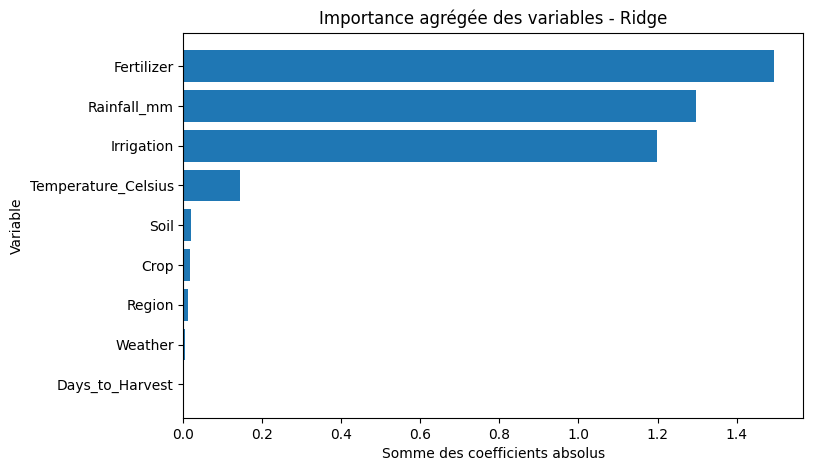

In [33]:
import matplotlib.pyplot as plt

top_coef = coef_grouped.head(10).sort_values("abs_coefficient")

plt.figure(figsize=(8, 5))
plt.barh(top_coef["source_feature"], top_coef["abs_coefficient"])
plt.xlabel("Somme des coefficients absolus")
plt.ylabel("Variable")
plt.title("Importance agrégée des variables - Ridge")
plt.show()

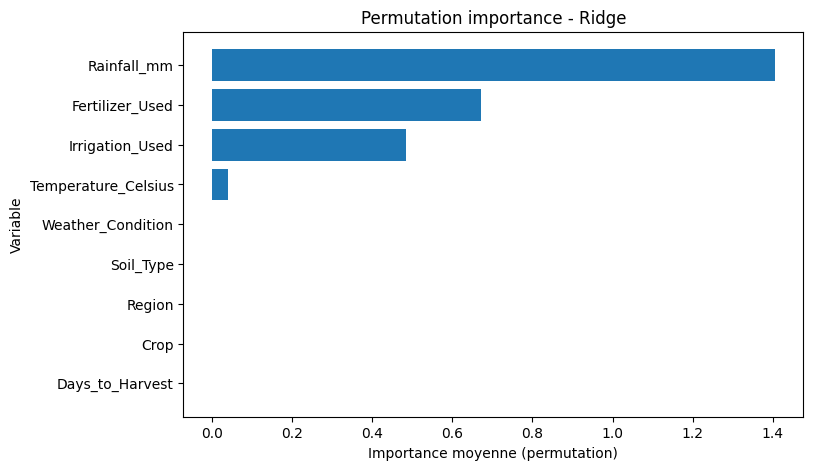

In [34]:
top_perm = perm_df.head(10).sort_values("importance_mean")

plt.figure(figsize=(8, 5))
plt.barh(top_perm["feature"], top_perm["importance_mean"])
plt.xlabel("Importance moyenne (permutation)")
plt.ylabel("Variable")
plt.title("Permutation importance - Ridge")
plt.show()

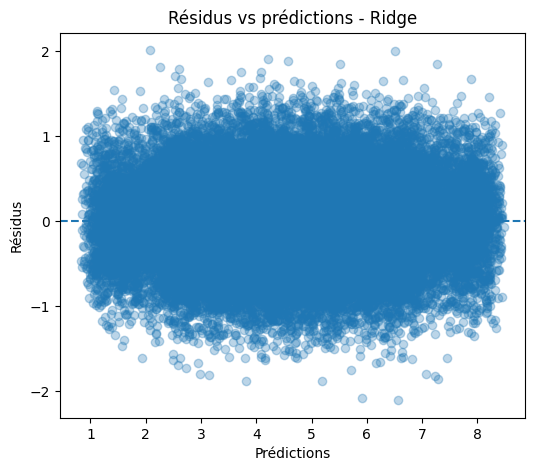

In [35]:
residuals = yb_test - champion_preds

plt.figure(figsize=(6, 5))
plt.scatter(champion_preds, residuals, alpha=0.3)
plt.axhline(0, linestyle="--")
plt.xlabel("Prédictions")
plt.ylabel("Résidus")
plt.title("Résidus vs prédictions - Ridge")
plt.show()

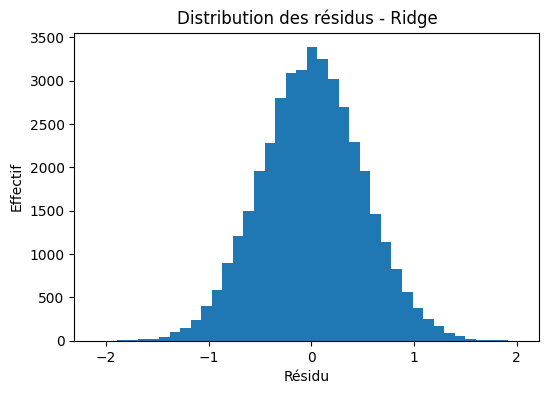

In [36]:
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=40)
plt.xlabel("Résidu")
plt.ylabel("Effectif")
plt.title("Distribution des résidus - Ridge")
plt.show()

## Simplification du modèle

In [37]:
ridge_min_features = [
    "Rainfall_mm",
    "Temperature_Celsius",
    "Fertilizer_Used",
    "Irrigation_Used",
]

ridge_mid_features = [
    "Rainfall_mm",
    "Temperature_Celsius",
    "Fertilizer_Used",
    "Irrigation_Used",
    "Region",
    "Soil_Type",
]

In [38]:
X_ridge_min = crop_aux_sample[ridge_min_features].copy()
y_ridge_min = crop_aux_sample[target_col].copy()

X_ridge_mid = crop_aux_sample[ridge_mid_features].copy()
y_ridge_mid = crop_aux_sample[target_col].copy()

In [39]:
ridge_min_numeric_features = [
    "Rainfall_mm",
    "Temperature_Celsius",
]

ridge_min_categorical_features = [
    "Fertilizer_Used",
    "Irrigation_Used",
]

ridge_mid_numeric_features = [
    "Rainfall_mm",
    "Temperature_Celsius",
]

ridge_mid_categorical_features = [
    "Fertilizer_Used",
    "Irrigation_Used",
    "Region",
    "Soil_Type",
]

In [40]:
for col in ridge_min_numeric_features:
    X_ridge_min[col] = pd.to_numeric(X_ridge_min[col], errors="coerce")

for col in ridge_min_categorical_features:
    X_ridge_min[col] = X_ridge_min[col].fillna("missing").astype(str)

for col in ridge_mid_numeric_features:
    X_ridge_mid[col] = pd.to_numeric(X_ridge_mid[col], errors="coerce")

for col in ridge_mid_categorical_features:
    X_ridge_mid[col] = X_ridge_mid[col].fillna("missing").astype(str)

In [41]:
Xrm_train, Xrm_test, yrm_train, yrm_test = train_test_split(
    X_ridge_min, y_ridge_min, test_size=0.2, random_state=random_state
)

Xrmd_train, Xrmd_test, yrmd_train, yrmd_test = train_test_split(
    X_ridge_mid, y_ridge_mid, test_size=0.2, random_state=random_state
)

In [42]:
def run_single_ridge_mlflow(
    X_train,
    X_test,
    y_train,
    y_test,
    dataset_name,
    numeric_features,
    categorical_features,
    alpha=1.0,
    stage="ridge_simplification",
):
    preprocessor = build_preprocessor(
        numeric_features=numeric_features,
        categorical_features=categorical_features,
    )

    model = Ridge(alpha=alpha)

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    with mlflow.start_run(run_name=f"{dataset_name}__ridge"):
        mlflow.set_tags({
            "project": "Projet-12",
            "notebook": "03_modeling_baseline",
            "stage": stage,
            "dataset_name": dataset_name,
            "model_name": "ridge",
        })

        mlflow.log_param("dataset_name", dataset_name)
        mlflow.log_param("model_name", "ridge")
        mlflow.log_param("alpha", alpha)
        mlflow.log_param("n_train_rows", len(X_train))
        mlflow.log_param("n_test_rows", len(X_test))
        mlflow.log_param("numeric_features", ", ".join(numeric_features))
        mlflow.log_param("categorical_features", ", ".join(categorical_features))

        pipe.fit(X_train, y_train)
        preds = pipe.predict(X_test)

        result = evaluate_regression(
            y_true=y_test,
            y_pred=preds,
            model_name="ridge",
            dataset_name=dataset_name,
        )

        mlflow.log_metric("rmse", result["rmse"])
        mlflow.log_metric("mae", result["mae"])
        mlflow.log_metric("r2", result["r2"])

    return pd.DataFrame([result])

In [43]:
results_ridge_min = run_single_ridge_mlflow(
    Xrm_train, Xrm_test, yrm_train, yrm_test,
    dataset_name="crop_aux_ridge_min",
    numeric_features=ridge_min_numeric_features,
    categorical_features=ridge_min_categorical_features,
)

results_ridge_mid = run_single_ridge_mlflow(
    Xrmd_train, Xrmd_test, yrmd_train, yrmd_test,
    dataset_name="crop_aux_ridge_mid",
    numeric_features=ridge_mid_numeric_features,
    categorical_features=ridge_mid_categorical_features,
)

display(pd.concat([results_all_extended, results_ridge_min, results_ridge_mid], ignore_index=True).sort_values(["dataset", "rmse"]))

,dataset,model,rmse,mae,r2
1,crop_aux_base,ridge,0.496723,0.396089,0.913939
6,crop_aux_base,catboost,0.497416,0.396681,0.913698
5,crop_aux_base,lightgbm,0.497990,0.397009,0.913499
3,crop_aux_base,hist_gbr,0.498269,0.397230,0.913402
4,crop_aux_base,xgboost,0.498590,0.397433,0.913290
2,crop_aux_base,random_forest,0.515372,0.410729,0.907355
0,crop_aux_base,dummy_mean,1.693210,1.385817,-0.000005
8,crop_aux_enriched,ridge,0.496710,0.396081,0.913943
13,crop_aux_enriched,catboost,0.497164,0.396507,0.913786
10,crop_aux_enriched,hist_gbr,0.498228,0.397223,0.913416


In [44]:
def run_cv_ridge(
    X,
    y,
    numeric_features,
    categorical_features,
    dataset_name,
    alpha=1.0,
    n_splits=5,
):
    preprocessor = build_preprocessor(
        numeric_features=numeric_features,
        categorical_features=categorical_features,
    )

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=alpha)),
    ])

    cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    scoring = {
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2",
    }

    scores = cross_validate(
        pipe,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )

    result = {
        "dataset": dataset_name,
        "model": "ridge_cv",
        "rmse_mean": -scores["test_rmse"].mean(),
        "rmse_std": scores["test_rmse"].std(),
        "mae_mean": -scores["test_mae"].mean(),
        "mae_std": scores["test_mae"].std(),
        "r2_mean": scores["test_r2"].mean(),
        "r2_std": scores["test_r2"].std(),
    }

    with mlflow.start_run(run_name=f"{dataset_name}__ridge_cv"):
        mlflow.set_tags({
            "project": "Projet-12",
            "notebook": "03_modeling_baseline",
            "stage": "cross_validation",
            "dataset_name": dataset_name,
            "model_name": "ridge_cv",
        })

        mlflow.log_param("dataset_name", dataset_name)
        mlflow.log_param("model_name", "ridge_cv")
        mlflow.log_param("alpha", alpha)
        mlflow.log_param("cv_n_splits", n_splits)

        for k, v in result.items():
            if isinstance(v, (int, float, np.floating)):
                mlflow.log_metric(k, float(v))

    return result

In [45]:
cv_results = pd.DataFrame([
    run_cv_ridge(
        X_base,
        y_base,
        numeric_features=base_numeric_features,
        categorical_features=base_categorical_features,
        dataset_name="crop_aux_base",
        alpha=1.0,
    ),
    run_cv_ridge(
        X_ridge_min,
        y_ridge_min,
        numeric_features=ridge_min_numeric_features,
        categorical_features=ridge_min_categorical_features,
        dataset_name="crop_aux_ridge_min",
        alpha=1.0,
    ),
    run_cv_ridge(
        X_ridge_mid,
        y_ridge_mid,
        numeric_features=ridge_mid_numeric_features,
        categorical_features=ridge_mid_categorical_features,
        dataset_name="crop_aux_ridge_mid",
        alpha=1.0,
    ),
])

cv_results.sort_values("rmse_mean")

,dataset,model,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
1,crop_aux_ridge_min,ridge_cv,0.499273,0.001786,0.398354,0.001765,0.913226,0.000700
2,crop_aux_ridge_mid,ridge_cv,0.499278,0.001788,0.398360,0.001763,0.913224,0.000702
0,crop_aux_base,ridge_cv,0.499304,0.001779,0.398377,0.001765,0.913215,0.000697


## Gridsearch

In [46]:
ridge_preprocessor = build_preprocessor(
    numeric_features=base_numeric_features,
    categorical_features=base_categorical_features,
)

ridge_pipe = Pipeline([
    ("preprocessor", ridge_preprocessor),
    ("model", Ridge()),
])

In [47]:
param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
}

In [48]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1,
)

grid.fit(X_base, y_base)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : 

In [49]:
print("Best params:", grid.best_params_)
print("Best score (RMSE):", -grid.best_score_)
print("Best estimator:", grid.best_estimator_)

Best params: {'model__alpha': 10.0}
Best score (RMSE): 0.4993043414040084
Best estimator: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Rainfall_mm',
                                                   'Temperature_Celsius',
                                                   'Days_to_Harvest']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Region', 'Soil_Type',
                                          

In [50]:
with mlflow.start_run(run_name="crop_aux_base__ridge_gridsearch"):
    mlflow.set_tags({
        "project": "Projet-12",
        "notebook": "03_modeling_baseline",
        "stage": "hyperparameter_tuning",
        "dataset_name": "crop_aux_base",
        "model_name": "ridge_gridsearch",
    })

    mlflow.log_param("cv_n_splits", 5)
    mlflow.log_param("param_grid_alpha", str(param_grid["model__alpha"]))
    mlflow.log_param("best_alpha", grid.best_params_["model__alpha"])
    mlflow.log_metric("best_cv_rmse", -grid.best_score_)

## Run sur full dataset

In [51]:
crop_aux_full = pd.read_csv(PROCESSED_DIR / "crop_aux_clean.csv")
print(crop_aux_full.shape)

(999769, 10)


In [52]:
ridge_base_features = [
    "Region",
    "Soil_Type",
    "Crop",
    "Rainfall_mm",
    "Temperature_Celsius",
    "Fertilizer_Used",
    "Irrigation_Used",
    "Weather_Condition",
    "Days_to_Harvest",
]

ridge_base_numeric_features = [
    "Rainfall_mm",
    "Temperature_Celsius",
    "Days_to_Harvest",
]

ridge_base_categorical_features = [
    "Region",
    "Soil_Type",
    "Crop",
    "Fertilizer_Used",
    "Irrigation_Used",
    "Weather_Condition",
]

In [53]:
ridge_min_features = [
    "Rainfall_mm",
    "Temperature_Celsius",
    "Fertilizer_Used",
    "Irrigation_Used",
]

ridge_min_numeric_features = [
    "Rainfall_mm",
    "Temperature_Celsius",
]

ridge_min_categorical_features = [
    "Fertilizer_Used",
    "Irrigation_Used",
]

In [54]:
ridge_mid_features = [
    "Rainfall_mm",
    "Temperature_Celsius",
    "Fertilizer_Used",
    "Irrigation_Used",
    "Region",
    "Soil_Type",
]

ridge_mid_numeric_features = [
    "Rainfall_mm",
    "Temperature_Celsius",
]

ridge_mid_categorical_features = [
    "Fertilizer_Used",
    "Irrigation_Used",
    "Region",
    "Soil_Type",
]

In [55]:
target_col = "Yield_tons_per_hectare"

X_ridge_base_full = crop_aux_full[ridge_base_features].copy()
y_ridge_base_full = crop_aux_full[target_col].copy()

X_ridge_min_full = crop_aux_full[ridge_min_features].copy()
y_ridge_min_full = crop_aux_full[target_col].copy()

X_ridge_mid_full = crop_aux_full[ridge_mid_features].copy()
y_ridge_mid_full = crop_aux_full[target_col].copy()

In [56]:
for col in ridge_base_numeric_features:
    X_ridge_base_full[col] = pd.to_numeric(X_ridge_base_full[col], errors="coerce")
for col in ridge_base_categorical_features:
    X_ridge_base_full[col] = X_ridge_base_full[col].fillna("missing").astype(str)

for col in ridge_min_numeric_features:
    X_ridge_min_full[col] = pd.to_numeric(X_ridge_min_full[col], errors="coerce")
for col in ridge_min_categorical_features:
    X_ridge_min_full[col] = X_ridge_min_full[col].fillna("missing").astype(str)

for col in ridge_mid_numeric_features:
    X_ridge_mid_full[col] = pd.to_numeric(X_ridge_mid_full[col], errors="coerce")
for col in ridge_mid_categorical_features:
    X_ridge_mid_full[col] = X_ridge_mid_full[col].fillna("missing").astype(str)

In [57]:
Xrb_train, Xrb_test, yrb_train, yrb_test = train_test_split(
    X_ridge_base_full, y_ridge_base_full, test_size=0.2, random_state=42
)

Xrmin_train, Xrmin_test, yrmin_train, yrmin_test = train_test_split(
    X_ridge_min_full, y_ridge_min_full, test_size=0.2, random_state=42
)

Xrmid_train, Xrmid_test, yrmid_train, yrmid_test = train_test_split(
    X_ridge_mid_full, y_ridge_mid_full, test_size=0.2, random_state=42
)

In [58]:
def run_single_ridge_mlflow(
    X_train,
    X_test,
    y_train,
    y_test,
    dataset_name,
    numeric_features,
    categorical_features,
    alpha=1.0,
    stage="ridge_full_dataset",
):
    preprocessor = build_preprocessor(
        numeric_features=numeric_features,
        categorical_features=categorical_features,
    )

    model = Ridge(alpha=alpha)

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    with mlflow.start_run(run_name=f"{dataset_name}__ridge"):
        mlflow.set_tags({
            "project": "Projet-12",
            "notebook": "03_modeling_baseline",
            "stage": stage,
            "dataset_name": dataset_name,
            "model_name": "ridge",
        })

        mlflow.log_param("dataset_name", dataset_name)
        mlflow.log_param("model_name", "ridge")
        mlflow.log_param("alpha", alpha)
        mlflow.log_param("n_train_rows", len(X_train))
        mlflow.log_param("n_test_rows", len(X_test))
        mlflow.log_param("numeric_features", ", ".join(numeric_features))
        mlflow.log_param("categorical_features", ", ".join(categorical_features))

        pipe.fit(X_train, y_train)
        preds = pipe.predict(X_test)

        result = evaluate_regression(
            y_true=y_test,
            y_pred=preds,
            model_name="ridge",
            dataset_name=dataset_name,
        )

        mlflow.log_metric("rmse", result["rmse"])
        mlflow.log_metric("mae", result["mae"])
        mlflow.log_metric("r2", result["r2"])

    return pd.DataFrame([result]), pipe

In [59]:
results_ridge_base_full, ridge_base_full_pipe = run_single_ridge_mlflow(
    Xrb_train, Xrb_test, yrb_train, yrb_test,
    dataset_name="crop_aux_ridge_base_full",
    numeric_features=ridge_base_numeric_features,
    categorical_features=ridge_base_categorical_features,
)

results_ridge_min_full, ridge_min_full_pipe = run_single_ridge_mlflow(
    Xrmin_train, Xrmin_test, yrmin_train, yrmin_test,
    dataset_name="crop_aux_ridge_min_full",
    numeric_features=ridge_min_numeric_features,
    categorical_features=ridge_min_categorical_features,
)

results_ridge_mid_full, ridge_mid_full_pipe = run_single_ridge_mlflow(
    Xrmid_train, Xrmid_test, yrmid_train, yrmid_test,
    dataset_name="crop_aux_ridge_mid_full",
    numeric_features=ridge_mid_numeric_features,
    categorical_features=ridge_mid_categorical_features,
)

results_ridge_full = pd.concat(
    [results_ridge_base_full, results_ridge_min_full, results_ridge_mid_full],
    ignore_index=True,
).sort_values("rmse")

results_ridge_full

,dataset,model,rmse,mae,r2
1,crop_aux_ridge_min_full,ridge,0.499268,0.398338,0.913235
0,crop_aux_ridge_base_full,ridge,0.499271,0.398339,0.913234
2,crop_aux_ridge_mid_full,ridge,0.499272,0.398340,0.913234


In [60]:
def run_cv_ridge_mlflow(
    X,
    y,
    numeric_features,
    categorical_features,
    dataset_name,
    alpha=1.0,
    n_splits=5,
):
    preprocessor = build_preprocessor(
        numeric_features=numeric_features,
        categorical_features=categorical_features,
    )

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=alpha)),
    ])

    cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    scoring = {
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2",
    }

    scores = cross_validate(
        pipe,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )

    result = {
        "dataset": dataset_name,
        "model": "ridge_cv",
        "rmse_mean": -scores["test_rmse"].mean(),
        "rmse_std": scores["test_rmse"].std(),
        "mae_mean": -scores["test_mae"].mean(),
        "mae_std": scores["test_mae"].std(),
        "r2_mean": scores["test_r2"].mean(),
        "r2_std": scores["test_r2"].std(),
    }

    with mlflow.start_run(run_name=f"{dataset_name}__ridge_cv"):
        mlflow.set_tags({
            "project": "Projet-12",
            "notebook": "03_modeling_baseline",
            "stage": "cross_validation_full",
            "dataset_name": dataset_name,
            "model_name": "ridge_cv",
        })

        mlflow.log_param("dataset_name", dataset_name)
        mlflow.log_param("alpha", alpha)
        mlflow.log_param("cv_n_splits", n_splits)

        for k, v in result.items():
            if isinstance(v, (int, float, np.floating)):
                mlflow.log_metric(k, float(v))

    return pd.DataFrame([result])

In [61]:
cv_results_full = run_cv_ridge_mlflow(
    X_ridge_min_full,
    y_ridge_min_full,
    numeric_features=ridge_min_numeric_features,
    categorical_features=ridge_min_categorical_features,
    dataset_name="crop_aux_ridge_min_full",
    alpha=1.0,
    n_splits=5,
)

cv_results_full

,dataset,model,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,crop_aux_ridge_min_full,ridge_cv,0.500122,0.000527,0.399103,0.000499,0.912958,0.000259


In [62]:
ridge_min_preprocessor = build_preprocessor(
    numeric_features=ridge_min_numeric_features,
    categorical_features=ridge_min_categorical_features,
)

ridge_min_pipe = Pipeline([
    ("preprocessor", ridge_min_preprocessor),
    ("model", Ridge()),
])

param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=ridge_min_pipe,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1,
)

grid.fit(X_ridge_min_full, y_ridge_min_full)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : 

In [63]:
print("Best params:", grid.best_params_)
print("Best CV RMSE:", -grid.best_score_)

Best params: {'model__alpha': 0.1}
Best CV RMSE: 0.5001217321101115


In [64]:
grid_results = pd.DataFrame(grid.cv_results_)[[
    "param_model__alpha",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
]].copy()

grid_results["mean_test_rmse"] = -grid_results["mean_test_score"]
grid_results["std_test_rmse"] = grid_results["std_test_score"]

grid_results.sort_values("rank_test_score")

,param_model__alpha,mean_test_score,std_test_score,rank_test_score,mean_test_rmse,std_test_rmse
2,0.100,-0.500122,0.000527,1,0.500122,0.000527
1,0.010,-0.500122,0.000527,2,0.500122,0.000527
0,0.001,-0.500122,0.000527,3,0.500122,0.000527
3,1.000,-0.500122,0.000527,4,0.500122,0.000527
4,10.000,-0.500122,0.000527,5,0.500122,0.000527
5,100.000,-0.500122,0.000527,6,0.500122,0.000527


In [65]:
with mlflow.start_run(run_name="crop_aux_ridge_min_full__gridsearch"):
    mlflow.set_tags({
        "project": "Projet-12",
        "notebook": "03_modeling_baseline",
        "stage": "hyperparameter_tuning_full",
        "dataset_name": "crop_aux_ridge_min_full",
        "model_name": "ridge_gridsearch",
    })

    mlflow.log_param("cv_n_splits", 5)
    mlflow.log_param("param_grid_alpha", str(param_grid["model__alpha"]))
    mlflow.log_param("best_alpha", grid.best_params_["model__alpha"])
    mlflow.log_metric("best_cv_rmse", -grid.best_score_)

## Tentative Catboost avec gridsearch

In [66]:
catboost_full_features = [
    "Region",
    "Soil_Type",
    "Crop",
    "Rainfall_mm",
    "Temperature_Celsius",
    "Fertilizer_Used",
    "Irrigation_Used",
    "Weather_Condition",
    "Days_to_Harvest",
]

catboost_numeric_features = [
    "Rainfall_mm",
    "Temperature_Celsius",
    "Days_to_Harvest",
]

catboost_categorical_features = [
    "Region",
    "Soil_Type",
    "Crop",
    "Fertilizer_Used",
    "Irrigation_Used",
    "Weather_Condition",
]

X_cat_full = crop_aux_full[catboost_full_features].copy()
y_cat_full = crop_aux_full[target_col].copy()

for col in catboost_numeric_features:
    X_cat_full[col] = pd.to_numeric(X_cat_full[col], errors="coerce")

for col in catboost_categorical_features:
    X_cat_full[col] = X_cat_full[col].fillna("missing").astype(str)

print(X_cat_full.shape, y_cat_full.shape)
print(X_cat_full.dtypes)

(999769, 9) (999769,)
Region                  object
Soil_Type               object
Crop                    object
Rainfall_mm            float64
Temperature_Celsius    float64
Fertilizer_Used         object
Irrigation_Used         object
Weather_Condition       object
Days_to_Harvest          int64
dtype: object


In [67]:
cat_model = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    random_state=42,
    verbose=0,
    allow_writing_files=False,
)

cat_param_grid = {
    "iterations": [300, 500],
    "depth": [4, 6],
    "learning_rate": [0.03, 0.05],
    "l2_leaf_reg": [3, 5],
}

In [68]:
cat_cv = KFold(n_splits=5, shuffle=True, random_state=42)

cat_grid = GridSearchCV(
    estimator=cat_model,
    param_grid=cat_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cat_cv,
    n_jobs=1,
    refit=True,
    verbose=2,
)

cat_grid.fit(
    X_cat_full,
    y_cat_full,
    cat_features=catboost_categorical_features,
)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END depth=4, iterations=300, l2_leaf_reg=3, learning_rate=0.03; total time=  38.5s
[CV] END depth=4, iterations=300, l2_leaf_reg=3, learning_rate=0.03; total time=  31.7s
[CV] END depth=4, iterations=300, l2_leaf_reg=3, learning_rate=0.03; total time=  30.3s
[CV] END depth=4, iterations=300, l2_leaf_reg=3, learning_rate=0.03; total time=  30.4s
[CV] END depth=4, iterations=300, l2_leaf_reg=3, learning_rate=0.03; total time=  30.8s
[CV] END depth=4, iterations=300, l2_leaf_reg=3, learning_rate=0.05; total time=  29.3s
[CV] END depth=4, iterations=300, l2_leaf_reg=3, learning_rate=0.05; total time=  29.2s
[CV] END depth=4, iterations=300, l2_leaf_reg=3, learning_rate=0.05; total time=  29.2s
[CV] END depth=4, iterations=300, l2_leaf_reg=3, learning_rate=0.05; total time=  28.7s
[CV] END depth=4, iterations=300, l2_leaf_reg=3, learning_rate=0.05; total time=  29.4s
[CV] END depth=4, iterations=300, l2_leaf_reg=5, learning_r

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","CatBoostRegre...42, verbose=0)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'depth': [4, 6], 'iterations': [300, 500], 'l2_leaf_reg': [3, 5], 'learning_rate': [0.03, 0.05]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation tim

In [69]:
print("Best params:", cat_grid.best_params_)
print("Best CV RMSE:", -cat_grid.best_score_)
print("Best estimator:", cat_grid.best_estimator_)

Best params: {'depth': 6, 'iterations': 500, 'l2_leaf_reg': 5, 'learning_rate': 0.03}
Best CV RMSE: 0.5003228944240818
Best estimator: CatBoostRegressor(allow_writing_files=False, depth=6, eval_metric='RMSE', iterations=500, l2_leaf_reg=5, learning_rate=0.03, loss_function='RMSE', random_state=42, verbose=0)


In [70]:
cat_grid_results = pd.DataFrame(cat_grid.cv_results_)[[
    "param_iterations",
    "param_depth",
    "param_learning_rate",
    "param_l2_leaf_reg",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
]].copy()

cat_grid_results["mean_test_rmse"] = -cat_grid_results["mean_test_score"]
cat_grid_results["std_test_rmse"] = cat_grid_results["std_test_score"]

cat_grid_results.sort_values("rank_test_score")

,param_iterations,param_depth,param_learning_rate,param_l2_leaf_reg,mean_test_score,std_test_score,rank_test_score,mean_test_rmse,std_test_rmse
14,500,6,0.03,5,-0.500323,0.000543,1,0.500323,0.000543
12,500,6,0.03,3,-0.500323,0.000538,2,0.500323,0.000538
10,300,6,0.03,5,-0.500344,0.000542,3,0.500344,0.000542
8,300,6,0.03,3,-0.500344,0.000537,4,0.500344,0.000537
4,500,4,0.03,3,-0.500350,0.000552,5,0.500350,0.000552
6,500,4,0.03,5,-0.500357,0.000557,6,0.500357,0.000557
13,500,6,0.05,3,-0.500364,0.000568,7,0.500364,0.000568
15,500,6,0.05,5,-0.500372,0.000568,8,0.500372,0.000568
0,300,4,0.03,3,-0.500409,0.000549,9,0.500409,0.000549
2,300,4,0.03,5,-0.500415,0.000555,10,0.500415,0.000555


In [71]:
best_idx = cat_grid.best_index_
best_std_rmse = cat_grid.cv_results_["std_test_score"][best_idx]

with mlflow.start_run(run_name="crop_aux_catboost_base_full__gridsearch"):
    mlflow.set_tags({
        "project": "Projet-12",
        "notebook": "03_modeling_baseline",
        "stage": "hyperparameter_tuning_full",
        "dataset_name": "crop_aux_catboost_base_full",
        "model_name": "catboost_gridsearch",
    })

    mlflow.log_param("cv_n_splits", 5)
    mlflow.log_param("cat_features", ", ".join(catboost_categorical_features))
    mlflow.log_param("param_grid_iterations", str(cat_param_grid["iterations"]))
    mlflow.log_param("param_grid_depth", str(cat_param_grid["depth"]))
    mlflow.log_param("param_grid_learning_rate", str(cat_param_grid["learning_rate"]))
    mlflow.log_param("param_grid_l2_leaf_reg", str(cat_param_grid["l2_leaf_reg"]))

    for k, v in cat_grid.best_params_.items():
        mlflow.log_param(f"best_{k}", v)

    mlflow.log_metric("best_cv_rmse", -cat_grid.best_score_)
    mlflow.log_metric("best_cv_rmse_std", best_std_rmse)

## Generation du modele champion

In [72]:
final_features = [
    "Rainfall_mm",
    "Temperature_Celsius",
    "Fertilizer_Used",
    "Irrigation_Used",
]

final_numeric_features = [
    "Rainfall_mm",
    "Temperature_Celsius",
]

final_categorical_features = [
    "Fertilizer_Used",
    "Irrigation_Used",
]

X_final = crop_aux_full[final_features].copy()
y_final = crop_aux_full[target_col].copy()

for col in final_numeric_features:
    X_final[col] = pd.to_numeric(X_final[col], errors="coerce")

for col in final_categorical_features:
    X_final[col] = X_final[col].fillna("missing").astype(str)

print(X_final.shape, y_final.shape)
print(X_final.dtypes)

(999769, 4) (999769,)
Rainfall_mm            float64
Temperature_Celsius    float64
Fertilizer_Used         object
Irrigation_Used         object
dtype: object


In [73]:
final_alpha = 0.1

final_preprocessor = build_preprocessor(
    numeric_features=final_numeric_features,
    categorical_features=final_categorical_features,
)

final_model = Ridge(alpha=final_alpha)

final_pipeline = Pipeline([
    ("preprocessor", final_preprocessor),
    ("model", final_model),
])

final_pipeline.fit(X_final, y_final)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [74]:
ARTIFACTS_DIR = ROOT / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = ARTIFACTS_DIR / "model.joblib"
META_PATH = ARTIFACTS_DIR / "model_meta.json"

In [75]:
joblib.dump(final_pipeline, MODEL_PATH)
print("Model saved to:", MODEL_PATH)

Model saved to: C:\Users\thoma\Documents\Openclassroom\Projet-12\artifacts\model.joblib


In [76]:
model_meta = {
    "model_name": "Ridge",
    "alpha": final_alpha,
    "target_name": target_col,
    "feature_names": final_features,
    "numeric_features": final_numeric_features,
    "categorical_features": final_categorical_features,
    "training_dataset": "crop_aux_full",
    "n_rows_train_full": int(len(X_final)),
    "selection_rationale": (
        "Choisi comme modèle final après comparison avec RandomForest, "
        "HistGradientBoosting, XGBoost, LightGBM and CatBoost. "
        "Le modèle Ridge simplifié a atteint les meilleures performances ou équivalentes "
        "tout en étant plus interprétable et plus facile à déployer."
    ),
    "reference_metrics": {
        "cv_rmse_mean": 0.5004833022024302,
        "cv_rmse_std": 0.000646,
        "cv_r2_mean": 0.912976,
        "holdout_rmse_full": 0.500774,
        "holdout_mae_full": 0.399552,
        "holdout_r2_full": 0.913014,
    },
}

with open(META_PATH, "w", encoding="utf-8") as f:
    json.dump(model_meta, f, indent=2, ensure_ascii=False)

print("Meta saved to:", META_PATH)

Meta saved to: C:\Users\thoma\Documents\Openclassroom\Projet-12\artifacts\model_meta.json


In [77]:
sample_input = X_final.head(100).copy()
sample_pred = final_pipeline.predict(sample_input)
signature = infer_signature(sample_input, sample_pred)

with mlflow.start_run(run_name="crop_aux_ridge_min_full__final_model"):
    mlflow.set_tags({
        "project": "Projet-12",
        "notebook": "03_modeling_baseline",
        "stage": "final_model",
        "dataset_name": "crop_aux_ridge_min_full",
        "model_name": "ridge_final",
        "champion": "true",
    })

    mlflow.log_param("model_name", "Ridge")
    mlflow.log_param("alpha", final_alpha)
    mlflow.log_param("target_name", target_col)
    mlflow.log_param("feature_names", ", ".join(final_features))
    mlflow.log_param("n_rows_train_full", len(X_final))

    mlflow.log_metric("cv_rmse_mean", 0.5004833022024302)
    mlflow.log_metric("cv_r2_mean", 0.912976)
    mlflow.log_metric("holdout_rmse_full", 0.500774)
    mlflow.log_metric("holdout_mae_full", 0.399552)
    mlflow.log_metric("holdout_r2_full", 0.913014)

    mlflow.log_artifact(str(META_PATH))

    mlflow.sklearn.log_model(
        sk_model=final_pipeline,
        name="model",
        signature=signature,
        input_example=sample_input,
    )

2026/03/26 12:48:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/26 12:48:16 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
